# Data Analysis

In [1]:
import pandas as pd
import numpy as np

# Load and clean the dataset
columns_needed = [
    "latitude", "longitud", "weathername", "lgt_condname", "hour",
    "day_weekname", "fatals", "statename", "cityname", "countyname"
]

df = pd.read_csv("../Data/USA_data/Accidents_2015_2023.csv", usecols=columns_needed, low_memory=False)

# Clean relevant fields
df["latitude"] = pd.to_numeric(df["latitude"], errors='coerce')
df["longitud"] = pd.to_numeric(df["longitud"], errors='coerce')
df["weathername"] = df["weathername"].astype(str).str.strip()
df["lgt_condname"] = df["lgt_condname"].astype(str).str.strip()
df["hour"] = pd.to_numeric(df["hour"], errors='coerce')
df["day_weekname"] = df["day_weekname"].astype(str).str.strip()
df["fatals"] = pd.to_numeric(df["fatals"], errors='coerce').fillna(0).astype(int)

# Drop rows with missing geospatial values
df = df.dropna(subset=["latitude", "longitud"])

# ------------------------
# 1. Grid-based hotspot analysis (5° x 5°)
# ------------------------
df["lat_grid"] = (df["latitude"] // 5) * 5
df["lon_grid"] = (df["longitud"] // 5) * 5
grid_summary = df.groupby(["lat_grid", "lon_grid"]).agg(
    Total_Accidents=("fatals", "count"),
    Total_Fatalities=("fatals", "sum"),
    Sample_State=("statename", lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown"),
    Sample_City=("cityname", lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown"),
    Sample_County=("countyname", lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
).reset_index()

# ------------------------
# 2. Weather condition vs number of accidents
# ------------------------
weather_summary = df.groupby("weathername").agg(
    Total_Accidents=("fatals", "count"),
    Total_Fatalities=("fatals", "sum")
).reset_index()

# ------------------------
# 3. Lighting condition vs number of accidents
# ------------------------
lighting_summary = df.groupby("lgt_condname").agg(
    Total_Accidents=("fatals", "count"),
    Total_Fatalities=("fatals", "sum")
).reset_index()

# ------------------------
# 4. Time of day vs accidents
# ------------------------
time_summary = df[df["hour"].notna()].groupby("hour").agg(
    Total_Accidents=("fatals", "count"),
    Total_Fatalities=("fatals", "sum")
).reset_index()

# ------------------------
# 5. Day of week vs accidents
# ------------------------
day_summary = df.groupby("day_weekname").agg(
    Total_Accidents=("fatals", "count"),
    Total_Fatalities=("fatals", "sum")
).reset_index()

# ------------------------
# 6. Fatality rate summary
# ------------------------
overall_fatality_rate = df["fatals"].sum() / len(df)

# ------------------------
# 7. Feature combinations: weather + lighting + hour + day
# ------------------------
combo_features = df[["weathername", "lgt_condname", "hour", "day_weekname", "fatals"]].dropna()
combo_features["hour"] = combo_features["hour"].astype(int)
combo_counts = combo_features.groupby(
    ["weathername", "lgt_condname", "hour", "day_weekname"]
).agg(
    Total_Accidents=("fatals", "count"),
    Total_Fatalities=("fatals", "sum")
).reset_index()
combo_counts["Fatality_Rate"] = combo_counts["Total_Fatalities"] / combo_counts["Total_Accidents"]

# ------------------------
# 8. Top combinations by accident count and fatality rate
# ------------------------
top_accident_combos = combo_counts.sort_values("Total_Accidents", ascending=False).head(20)
top_fatality_combos = combo_counts[combo_counts["Total_Accidents"] > 10].sort_values("Fatality_Rate", ascending=False).head(20)

# ------------------------
# Save outputs
# ------------------------
grid_summary.to_csv("grid_summary.csv", index=False)
weather_summary.to_csv("weather_summary.csv", index=False)
lighting_summary.to_csv("lighting_summary.csv", index=False)
time_summary.to_csv("time_summary.csv", index=False)
day_summary.to_csv("day_summary.csv", index=False)
combo_counts.to_csv("all_combinations.csv", index=False)
top_accident_combos.to_csv("top_accident_combos.csv", index=False)
top_fatality_combos.to_csv("top_fatality_combos.csv", index=False)

# Optional print
print("Overall Fatality Rate:", round(overall_fatality_rate, 4))


Overall Fatality Rate: 1.0858


In [2]:
import pandas as pd

# Define thresholds
MIN_ACCIDENTS_FOR_FATALITY_RANKING = 10

# Load all summaries
grid_summary = pd.read_csv("grid_summary.csv")
weather_summary = pd.read_csv("weather_summary.csv")
lighting_summary = pd.read_csv("lighting_summary.csv")
time_summary = pd.read_csv("time_summary.csv")
day_summary = pd.read_csv("day_summary.csv")
combo_counts = pd.read_csv("all_combinations.csv")

# Add fatality rate if missing
for df in [grid_summary, weather_summary, lighting_summary, time_summary, day_summary]:
    if "Fatality_Rate" not in df.columns:
        df["Fatality_Rate"] = df["Total_Fatalities"] / df["Total_Accidents"]

# Extract top 20 by accident count and fatality rate (with enough volume)
top_20 = {
    "Top Grid Hotspots (by Accident Count)": grid_summary.sort_values("Total_Accidents", ascending=False).head(20),
    "Top Weather Conditions (by Accident Count)": weather_summary.sort_values("Total_Accidents", ascending=False).head(20),
    "Top Lighting Conditions (by Accident Count)": lighting_summary.sort_values("Total_Accidents", ascending=False).head(20),
    "Top Time of Day (by Accident Count)": time_summary.sort_values("Total_Accidents", ascending=False).head(20),
    "Top Days of Week (by Accident Count)": day_summary.sort_values("Total_Accidents", ascending=False).head(20),
    "Top Combined Features (by Accident Count)": combo_counts.sort_values("Total_Accidents", ascending=False).head(20),
    "Top Combined Features (by Fatality Rate)": combo_counts[combo_counts["Total_Accidents"] > MIN_ACCIDENTS_FOR_FATALITY_RANKING]
        .sort_values("Fatality_Rate", ascending=False).head(20)
}

# Save each to separate CSV
for title, df in top_20.items():
    filename = title.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_") + ".csv"
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")


Saved: top_grid_hotspots_by_accident_count.csv
Saved: top_weather_conditions_by_accident_count.csv
Saved: top_lighting_conditions_by_accident_count.csv
Saved: top_time_of_day_by_accident_count.csv
Saved: top_days_of_week_by_accident_count.csv
Saved: top_combined_features_by_accident_count.csv
Saved: top_combined_features_by_fatality_rate.csv


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

# Load all relevant CSVs
lighting = pd.read_csv("lighting_summary.csv")
weather = pd.read_csv("weather_summary.csv")
hour = pd.read_csv("time_summary.csv")
day = pd.read_csv("day_summary.csv")
grid = pd.read_csv("grid_summary.csv")
combo = pd.read_csv("all_combinations.csv")

# Compute fatality rates
for df in [lighting, weather, hour, day, grid, combo]:
    if 'Total_Accidents' in df.columns and 'Total_Fatalities' in df.columns:
        df["Fatality_Rate"] = df["Total_Fatalities"] / df["Total_Accidents"]

# Output directory
charts_dir = "multiple_charts"
os.makedirs(charts_dir, exist_ok=True)

# Chart 1: Boxplot of Fatality Rate by Lighting
plt.figure()
sns.boxplot(data=combo, x="lgt_condname", y="Fatality_Rate")
plt.title("Fatality Rate Distribution by Lighting")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_dir}/boxplot_fatality_lighting.png")
plt.close()

# Chart 2: Boxplot of Fatality Rate by Weather
plt.figure()
sns.boxplot(data=combo, x="weathername", y="Fatality_Rate")
plt.title("Fatality Rate Distribution by Weather")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_dir}/boxplot_fatality_weather.png")
plt.close()

# Chart 3: Heatmap - Fatality Rate by Hour and Day
heat_df = combo.pivot_table(index="hour", columns="day_weekname", values="Fatality_Rate", aggfunc="mean")
plt.figure(figsize=(10, 6))
sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="Reds")
plt.title("Heatmap of Fatality Rate by Hour and Day")
plt.tight_layout()
plt.savefig(f"{charts_dir}/heatmap_hour_day_fatality.png")
plt.close()

# Chart 4: Heatmap - Total Accidents by Hour and Day
heat_df2 = combo.pivot_table(index="hour", columns="day_weekname", values="Total_Accidents", aggfunc="sum")
plt.figure(figsize=(10, 6))
sns.heatmap(heat_df2, annot=True, fmt=".0f", cmap="Blues")
plt.title("Heatmap of Accident Volume by Hour and Day")
plt.tight_layout()
plt.savefig(f"{charts_dir}/heatmap_hour_day_volume.png")
plt.close()

# Chart 5: Fatality Rate by Combined Lighting & Weather
combo['Lighting+Weather'] = combo['lgt_condname'] + " + " + combo['weathername']
top_combo = combo.sort_values("Fatality_Rate", ascending=False).dropna().head(20)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_combo, x="Fatality_Rate", y="Lighting+Weather", palette="magma")
plt.title("Top 20 High Fatality Lighting + Weather Combinations")
plt.tight_layout()
plt.savefig(f"{charts_dir}/barplot_lighting_weather_combo.png")
plt.close()

# Chart 6: Grid Hotspots Map Representation
top_grids = grid.sort_values("Total_Accidents", ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=top_grids, x="lon_grid", y="lat_grid", size="Total_Accidents", hue="Fatality_Rate", palette="coolwarm", sizes=(50, 500), legend=False)
plt.title("Top Grid Hotspots (Lat/Lon) by Fatality Rate and Accident Volume")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(f"{charts_dir}/scatter_grid_hotspots.png")
plt.close()

# Output folder path for review
charts_dir


C:\Users\Fatima Azfar\AppData\Local\Temp\ipykernel_4084\2011486240.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_combo, x="Fatality_Rate", y="Lighting+Weather", palette="magma")


'multiple_charts'

In [5]:
import pandas as pd
import folium
from folium.plugins import HeatMap
import os

# Load grid data
grid = pd.read_csv("grid_summary.csv")
grid["Fatality_Rate"] = grid["Total_Fatalities"] / grid["Total_Accidents"]

# Create HTML dashboard with map showing grid cell rectangles with color based on fatality rate
map_center = [37.0, -95.0]
fol_map = folium.Map(location=map_center, zoom_start=5, tiles="cartodbpositron")

# Normalize fatality rate for color scaling
min_rate = grid["Fatality_Rate"].min()
max_rate = grid["Fatality_Rate"].max()
rate_range = max_rate - min_rate

def rate_color(rate):
    norm = (rate - min_rate) / rate_range
    if norm > 0.9:
        return "#800026"
    elif norm > 0.75:
        return "#BD0026"
    elif norm > 0.5:
        return "#E31A1C"
    elif norm > 0.3:
        return "#FC4E2A"
    elif norm > 0.1:
        return "#FD8D3C"
    else:
        return "#FEB24C"

# Add rectangles to map
for _, row in grid.iterrows():
    lat = row["lat_grid"]
    lon = row["lon_grid"]
    lat_bounds = [lat, lat + 5]
    lon_bounds = [lon, lon + 5]
    popup_text = (
        f"Grid: ({lat}, {lon})<br>"
        f"Accidents: {int(row['Total_Accidents'])}<br>"
        f"Fatalities: {int(row['Total_Fatalities'])}<br>"
        f"Fatality Rate: {row['Fatality_Rate']:.2f}<br>"
        f"State: {row.get('Sample_State', 'N/A')}<br>"
        f"City: {row.get('Sample_City', 'N/A')}<br>"
        f"County: {row.get('Sample_County', 'N/A')}"
    )
    folium.Rectangle(
        bounds=[[lat_bounds[0], lon_bounds[0]], [lat_bounds[1], lon_bounds[1]]],
        color=rate_color(row["Fatality_Rate"]),
        fill=True,
        fill_opacity=0.5,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(fol_map)

# Add heatmap layer
heat_data = grid[["lat_grid", "lon_grid", "Total_Accidents"]].copy()
heat_data["weight"] = heat_data["Total_Accidents"] / heat_data["Total_Accidents"].max()
heat_points = [[r["lat_grid"] + 2.5, r["lon_grid"] + 2.5, r["weight"]] for _, r in heat_data.iterrows()]
HeatMap(heat_points, radius=25, blur=15).add_to(fol_map)

# Save map
dashboard_path = "High_Level_Hotspot_Dashboard.html"
fol_map.save(dashboard_path)

dashboard_path

'High_Level_Hotspot_Dashboard.html'

In [9]:
import streamlit as st
import folium
from folium.plugins import HeatMap
from streamlit_folium import st_folium
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data again in this session
df = pd.read_csv("../Data/USA_data/Accidents_2015_2023.csv", usecols=[
    "hour", "day_weekname", "month", "latitude", "longitud", "countyname",
    "cityname", "lgt_condname", "weathername", "fatals"
])
df = df.dropna(subset=["latitude", "longitud", "lgt_condname", "weathername", "hour", "day_weekname", "fatals"])
df["lat_grid"] = (df["latitude"] // 0.5) * 0.5
df["lon_grid"] = (df["longitud"] // 0.5) * 0.5

# Precompute tables
lighting = df["lgt_condname"].value_counts().reset_index()
lighting.columns = ["Lighting Condition", "Accident Count"]

weather = df["weathername"].value_counts().reset_index()
weather.columns = ["Weather Condition", "Accident Count"]

temporal = df.groupby(["day_weekname", "hour"]).size().reset_index(name="Accident Count")
temporal = temporal.sort_values("Accident Count", ascending=False).head(20)

grid_summary = df.groupby(["lat_grid", "lon_grid"]).agg(
    Accident_Count=("fatals", "size"),
    Total_Fatalities=("fatals", "sum"),
    Sample_County=("countyname", "first"),
    Sample_City=("cityname", "first")
).reset_index().sort_values("Accident_Count", ascending=False)

fatality_lighting = df.groupby("lgt_condname").agg(
    Total_Accidents=("fatals", "size"),
    Total_Fatalities=("fatals", "sum")
).assign(Fatality_Rate=lambda x: (x["Total_Fatalities"] / x["Total_Accidents"]).round(2)).reset_index()

fatality_weather = df.groupby("weathername").agg(
    Total_Accidents=("fatals", "size"),
    Total_Fatalities=("fatals", "sum")
).assign(Fatality_Rate=lambda x: (x["Total_Fatalities"] / x["Total_Accidents"]).round(2)).reset_index()

# Create dashboard app
dashboard_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from streamlit_folium import st_folium

st.set_page_config(layout="wide")
st.title("🚨 USA Traffic Accident Analysis Dashboard (2015–2023)")

st.header("1. Accident Frequency by Lighting Condition")
fig1, ax1 = plt.subplots()
sns.barplot(data=lighting, x="Lighting Condition", y="Accident Count", ax=ax1)
plt.xticks(rotation=45)
st.pyplot(fig1)

st.header("2. Accident Frequency by Weather Condition")
fig2, ax2 = plt.subplots()
sns.barplot(data=weather, x="Weather Condition", y="Accident Count", ax=ax2)
plt.xticks(rotation=45)
st.pyplot(fig2)

st.header("3. Top 20 Temporal Accident Patterns")
st.dataframe(temporal)

st.header("4. Top 20 Grid Hotspots")
st.dataframe(grid_summary.head(20))

st.header("5. Fatality Rate by Lighting")
fig3, ax3 = plt.subplots()
sns.barplot(data=fatality_lighting, x="lgt_condname", y="Fatality_Rate", ax=ax3)
plt.xticks(rotation=45)
st.pyplot(fig3)

st.header("6. Fatality Rate by Weather")
fig4, ax4 = plt.subplots()
sns.barplot(data=fatality_weather, x="weathername", y="Fatality_Rate", ax=ax4)
plt.xticks(rotation=45)
st.pyplot(fig4)

st.header("7. Heatmap of Accident Hotspots (USA Grid)")
map_center = [37.0, -95.0]
heatmap_data = [[r["lat_grid"] + 0.25, r["lon_grid"] + 0.25, r["Accident_Count"]] for _, r in grid_summary.iterrows()]
m = folium.Map(location=map_center, zoom_start=5, tiles="cartodbpositron")
HeatMap(heatmap_data, radius=12).add_to(m)
st_folium(m, width=700, height=500)
"""

# # Save the Streamlit dashboard as a Python script
# dashboard_file = "accident_dashboard.py"
# with open(dashboard_file, "w") as f:
#     f.write(dashboard_code)

# dashboard_file
# 

In [10]:
df.shape

(324580, 12)

In [ ]:
import pandas as pd

# Load the CSV file
file_path = "../Data/USA_data/Accidents_2015_2023.csv"
data = pd.read_csv(file_path)

# Print unique category names for each column
for column in data.columns:
    print(f"Unique values in column '{column}':")
    print(data[column].unique())
    print()

C:\Users\Fatima Azfar\AppData\Local\Temp\ipykernel_12352\1267173359.py:5: DtypeWarning: Columns (40,42,64,66,86,88,90) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


Unique values in column 'caseyear':
[2019 2020 2021 2022]

Unique values in column 'state':
[ 1  2  4  5  6  8  9 10 11 12 13 15 16 17 18 19 20 21 22 23 24 25 26 27
 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
 53 54 55 56]

Unique values in column 'st_case':
[ 10001  10002  10003 ... 530728 530729 530730]

Unique values in column 'statename':
['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Puerto Rico' 'Rhode Island'
 'South Carolina' 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont'
 'Virginia' 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming']

Unique

In [1]:
# Analyze accident frequencies by lighting and weather conditions
import pandas as pd

df = pd.read_csv("rule_based_accident_prediction/accident_fastapi/data/Accidents_2019_2023.CSV")
# Count total accidents for each lighting condition
lighting_accidents = df["lgt_condname"].value_counts().reset_index()
lighting_accidents.columns = ["Lighting Condition", "Accident Count"]

# Count total accidents for each primary weather condition
weather1_accidents = df["weather1name"].value_counts().reset_index()
weather1_accidents.columns = ["Primary Weather Condition", "Accident Count"]

# Count total accidents for combined weather1 + lighting
combined_weather_lighting = df.groupby(["weather1name", "lgt_condname"]).size().reset_index(name="Accident Count")

print("Accidents by Lighting Condition:")
print(lighting_accidents)
print("\nAccidents by Primary Weather Condition:")
print(weather1_accidents)

C:\Users\Fatima Azfar\AppData\Local\Temp\ipykernel_16788\1157682162.py:4: DtypeWarning: Columns (40,42,64,66,86,88,90) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("rule_based_accident_prediction/accident_fastapi/data/Accidents_2019_2023.CSV")


Accidents by Lighting Condition:
        Lighting Condition  Accident Count
0                 Daylight           68188
1       Dark - Not Lighted           40682
2           Dark - Lighted           31579
3                     Dusk            3589
4                     Dawn            2759
5  Dark - Unknown Lighting            1637
6      Reported as Unknown             726
7             Not Reported             284
8                    Other              77

Accidents by Primary Weather Condition:
   Primary Weather Condition  Accident Count
0                      Clear           22922
1                     Cloudy            4988
2                       Rain            2532
3               Not Reported            2325
4           Fog, Smog, Smoke             342
5                       Snow             308
6        Reported as Unknown             167
7          Severe Crosswinds              48
8              Sleet or Hail              39
9   Freezing Rain or Drizzle              33
1

In [17]:
import pandas as pd

df = pd.read_csv("rule_based_accident_prediction/accident_fastapi/data/Accidents_2015_2018.CSV")
df2 = pd.read_csv("rule_based_accident_prediction/accident_fastapi/data/Accidents_2019_2023.CSV")

C:\Users\Fatima Azfar\AppData\Local\Temp\ipykernel_16788\3137206156.py:4: DtypeWarning: Columns (41,43,65,67,87,89,91) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("rule_based_accident_prediction/accident_fastapi/data/Accidents_2019_2023.CSV")


In [20]:
print(len(df.columns))
df.columns

94


Index(['caseyear', 'state', 'st_case', 'statename', 've_total', 've_forms',
       'pvh_invl', 'peds', 'pernotmvit', 'permvit', 'persons', 'county',
       'countyname', 'city', 'cityname', 'day', 'dayname', 'month',
       'monthname', 'year', 'day_week', 'day_weekname', 'hour', 'hourname',
       'minute', 'minutename', 'nhs', 'nhsname', 'rur_urb', 'rur_urbname',
       'func_sys', 'func_sysname', 'rd_owner', 'rd_ownername', 'route',
       'routename', 'tway_id', 'tway_id2', 'milept', 'mileptname', 'latitude',
       'latitudename', 'longitud', 'longitudname', 'sp_jur', 'sp_jurname',
       'harm_ev', 'harm_evname', 'man_coll', 'man_collname', 'reljct1',
       'reljct1name', 'reljct2', 'reljct2name', 'typ_int', 'typ_intname',
       'wrk_zone', 'wrk_zonename', 'road_fnc', 'road_fncname', 'rel_road',
       'rel_roadname', 'lgt_cond', 'lgt_condname', 'weather1', 'weather1name',
       'weather2', 'weather2name', 'weather', 'weathername', 'sch_bus',
       'sch_busname', 'rail', 'rai

In [21]:
print(len(df2.columns))
df2.columns

94


Index(['caseyear', 'state', 'st_case', 'statename', 've_total', 've_forms',
       'pvh_invl', 'peds', 'pernotmvit', 'permvit', 'persons', 'county',
       'countyname', 'city', 'cityname', 'day', 'dayname', 'month',
       'monthname', 'year', 'day_week', 'day_weekname', 'hour', 'hourname',
       'minute', 'minutename', 'nhs', 'nhsname', 'rur_urb', 'rur_urbname',
       'func_sys', 'func_sysname', 'rd_owner', 'rd_ownername', 'route',
       'routename', 'tway_id', 'tway_id2', 'milept', 'mileptname', 'latitude',
       'latitudename', 'longitud', 'longitudname', 'sp_jur', 'sp_jurname',
       'harm_ev', 'harm_evname', 'man_coll', 'man_collname', 'reljct1',
       'reljct1name', 'reljct2', 'reljct2name', 'typ_int', 'typ_intname',
       'wrk_zone', 'wrk_zonename', 'road_fnc', 'road_fncname', 'rel_road',
       'rel_roadname', 'lgt_cond', 'lgt_condname', 'weather1', 'weather1name',
       'weather2', 'weather2name', 'weather', 'weathername', 'sch_bus',
       'sch_busname', 'rail', 'rai

In [8]:
# Select only the columns that are available before accidents happen (context-aware)
pre_accident_columns = [
    'caseyear', 'state', 'st_case', 'statename', 've_total', 've_forms',
    'pvh_invl', 'peds', 'pernotmvit', 'permvit', 'persons', 'county',
    'countyname', 'city', 'cityname', 'day', 'month', 'monthname', 'year',
    'day_week', 'day_weekname', 'hour', 'hourname', 'minute', 'minutename',
    'nhs', 'nhsname', 'rur_urb', 'rur_urbname', 'func_sys', 'func_sysname',
    'rd_owner', 'rd_ownername', 'route', 'routename', 'tway_id', 'tway_id2',
    'milept', 'mileptname', 'latitude', 'latitudename', 'longitud',
    'longitudname', 'sp_jur', 'sp_jurname', 'harm_ev', 'harm_evname',
    'man_coll', 'man_collname', 'reljct1', 'reljct1name', 'reljct2',
    'reljct2name', 'typ_int', 'typ_intname', 'wrk_zone', 'wrk_zonename',
    'road_fnc', 'road_fncname', 'rel_road', 'rel_roadname', 'lgt_cond',
    'lgt_condname', 'weather1', 'weather1name', 'weather2', 'weather2name',
    'weather', 'weathername', 'sch_bus', 'sch_busname', 'rail', 'railname'
]

# Subset of dataframe
df_subset = df[pre_accident_columns].copy()

# Clean and cast important fields
df_subset["hour"] = pd.to_numeric(df_subset["hour"], errors='coerce')
df_subset["day_weekname"] = df_subset["day_weekname"].astype(str).str.strip()
df_subset["weathername"] = df_subset["weathername"].astype(str).str.strip()
df_subset["lgt_condname"] = df_subset["lgt_condname"].astype(str).str.strip()

# Analyze patterns: combo of day, hour, lighting, weather
patterns = df_subset.groupby([
    "day_weekname", "hour", "lgt_condname", "weathername"
]).size().reset_index(name="Accident Count").sort_values("Accident Count", ascending=False)

patterns

,day_weekname,hour,lgt_condname,weathername,Accident Count
324,Friday,15,Daylight,Clear,856
1554,Saturday,16,Daylight,Clear,804
1529,Saturday,15,Daylight,Clear,786
348,Friday,16,Daylight,Clear,782
2208,Sunday,16,Daylight,Clear,772
...,...,...,...,...,...
2021,Sunday,6,Dawn,Reported as Unknown,1
2018,Sunday,6,Dawn,Freezing Rain or Drizzle,1
4164,Wednesday,23,Dusk,Cloudy,1
4145,Wednesday,22,Reported as Unknown,Reported as Unknown,1


In [11]:
import numpy as np

# Filter out rows with missing coordinates
df_grid = df_subset.dropna(subset=["latitude", "longitud"]).copy()

# Define grid step size (degrees)
lat_step = 0.5
lon_step = 0.5

# Define bounding box for continental USA
lat_min, lat_max = 24.5, 49.5
lon_min, lon_max = -125, -66.5

# Create bins
lat_bins = np.arange(lat_min, lat_max + lat_step, lat_step)
lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)

# Assign grid indices
df_grid["grid_lat"] = np.searchsorted(lat_bins, df_grid["latitude"]) - 1
df_grid["grid_lon"] = np.searchsorted(lon_bins, df_grid["longitud"]) - 1

# Filter valid grid cells
df_grid = df_grid[
    (df_grid["grid_lat"] >= 0) & (df_grid["grid_lat"] < len(lat_bins) - 1) &
    (df_grid["grid_lon"] >= 0) & (df_grid["grid_lon"] < len(lon_bins) - 1)
]

# Group by grid cell and count accidents
grid_accident_counts = df_grid.groupby(["grid_lat", "grid_lon"]).size().reset_index(name="Accident Count")
grid_accident_counts["lat_center"] = grid_accident_counts["grid_lat"].apply(lambda x: lat_bins[x] + lat_step / 2)
grid_accident_counts["lon_center"] = grid_accident_counts["grid_lon"].apply(lambda x: lon_bins[x] + lon_step / 2)

grid_accident_counts.sort_values("Accident Count", ascending=False, inplace=True)

grid_accident_counts

,grid_lat,grid_lon,Accident Count,lat_center,lon_center
2046,34,74,1292,41.75,-87.75
623,18,81,1288,33.75,-84.25
120,10,59,1235,29.75,-95.25
448,16,56,1220,32.75,-96.75
10,2,89,1203,25.75,-80.25
...,...,...,...,...,...
3113,48,22,1,48.75,-113.75
3115,48,24,1,48.75,-112.75
3121,48,39,1,48.75,-105.25
3094,47,63,1,48.25,-93.25


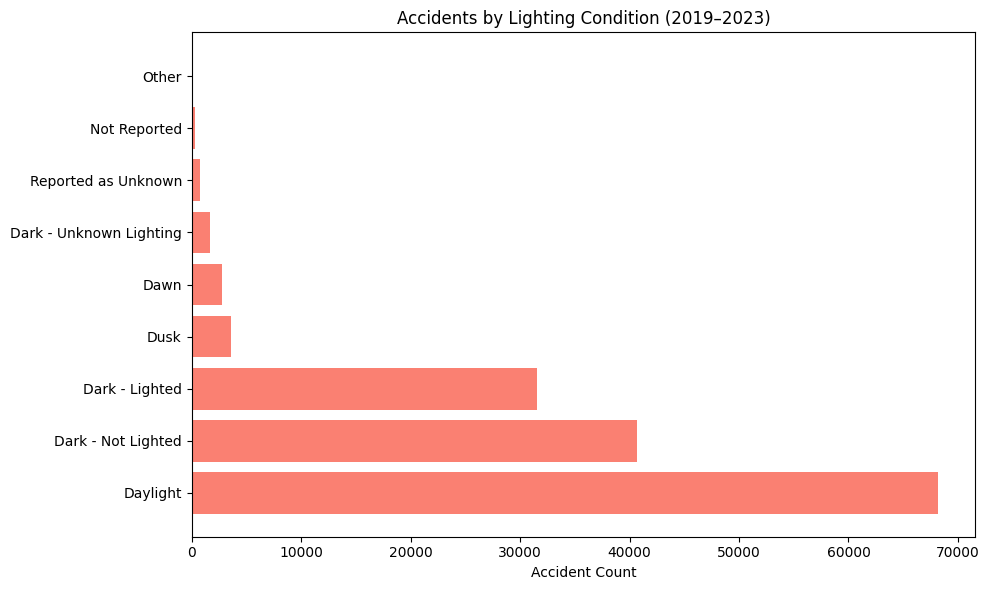

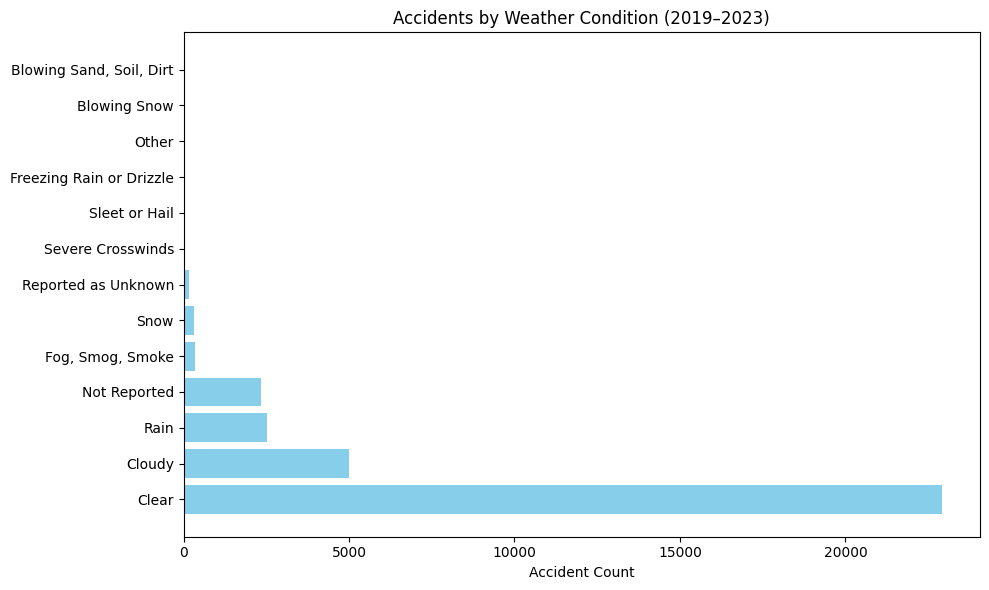

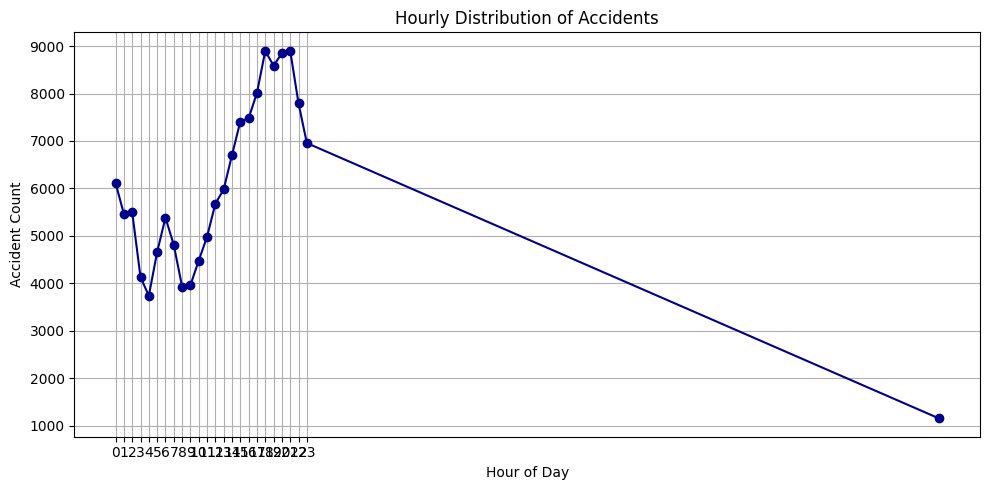

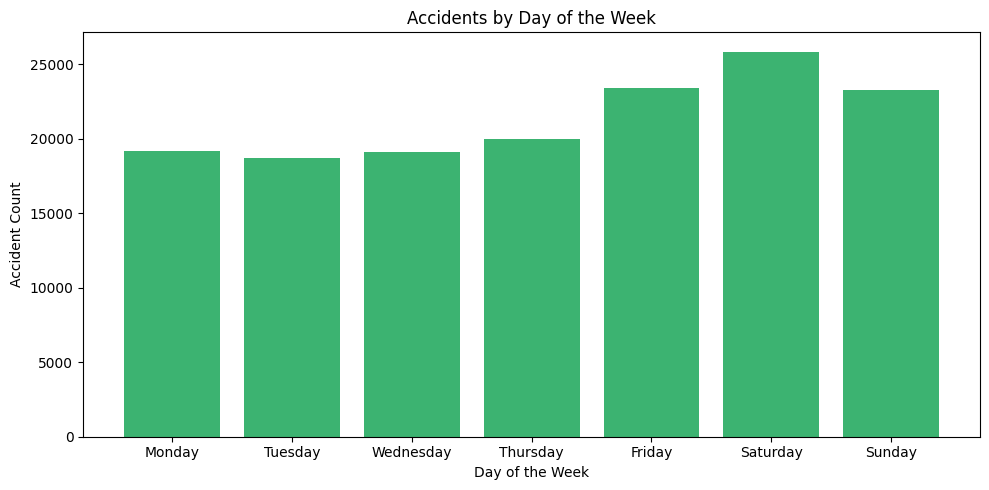

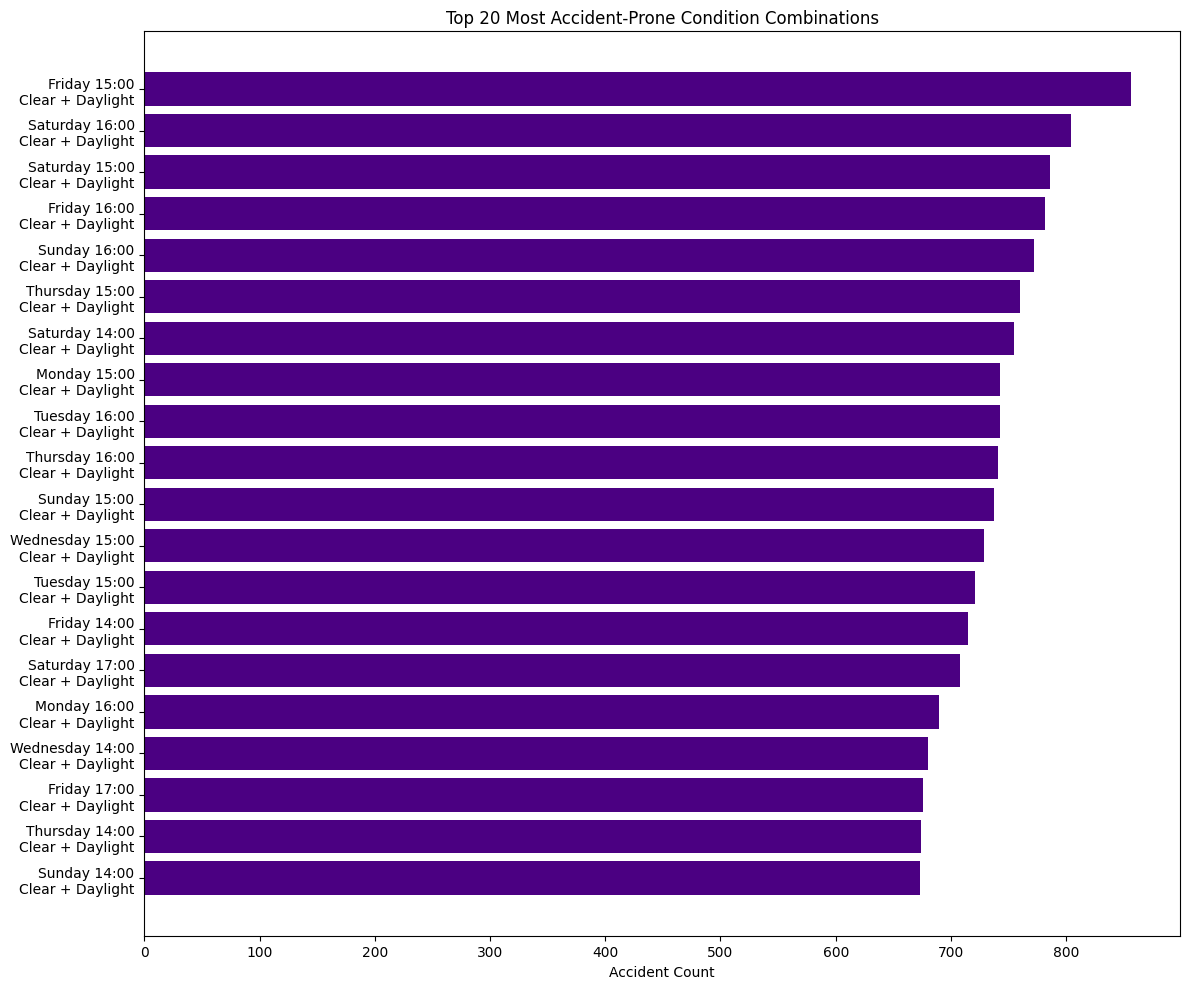

In [14]:
import matplotlib.pyplot as plt

# Recalculate key plots using pure matplotlib to avoid seaborn/scipy dependencies

# Plot 1: Lighting Condition vs. Accident Count
plt.figure(figsize=(10, 6))
lighting_labels = lighting_accidents["Lighting Condition"]
lighting_values = lighting_accidents["Accident Count"]
plt.barh(lighting_labels, lighting_values, color='salmon')
plt.title("Accidents by Lighting Condition (2019–2023)")
plt.xlabel("Accident Count")
plt.tight_layout()
plt.show()
plt.close()

# Plot 2: Weather Condition vs. Accident Count
plt.figure(figsize=(10, 6))
weather_labels = weather1_accidents["Primary Weather Condition"]
weather_values = weather1_accidents["Accident Count"]
plt.barh(weather_labels, weather_values, color='skyblue')
plt.title("Accidents by Weather Condition (2019–2023)")
plt.xlabel("Accident Count")
plt.tight_layout()
plt.show()
plt.close()

# Plot 3: Hourly Distribution of Accidents
hourly_accidents = df_subset["hour"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.plot(hourly_accidents.index, hourly_accidents.values, marker='o', linestyle='-', color='darkblue')
plt.title("Hourly Distribution of Accidents")
plt.xlabel("Hour of Day")
plt.ylabel("Accident Count")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

# Plot 4: Weekday Distribution
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_accidents = df_subset["day_weekname"].value_counts().reindex(weekday_order)
plt.figure(figsize=(10, 5))
plt.bar(weekday_accidents.index, weekday_accidents.values, color='mediumseagreen')
plt.title("Accidents by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Accident Count")
plt.tight_layout()
plt.show()
plt.close()

# Plot 5: Top 20 High-Risk Combinations
top_combos = patterns.head(20).copy()
combo_labels = top_combos.apply(lambda r: f"{r['day_weekname']} {int(r['hour'])}:00\n{r['weathername']} + {r['lgt_condname']}", axis=1)
plt.figure(figsize=(12, 10))
plt.barh(combo_labels[::-1], top_combos["Accident Count"][::-1], color='indigo')
plt.title("Top 20 Most Accident-Prone Condition Combinations")
plt.xlabel("Accident Count")
plt.tight_layout()
plt.show()
plt.close()